# Polar Verity Sense Offline PPI — Time Alignment Strategies

Цей notebook порівнює дві стратегії для проблемних `timeStamp` у Polar Verity Sense offline PPI:

1. **Strategy A — anchor interpolation**  
   Знаходимо timestamp-и, які схожі на реальні опорні точки, і інтерполюємо час між ними.

2. **Strategy B — cumulative PPI reconstruction**  
   Ігноруємо raw `timeStamp` як beat-time і будуємо timeline через накопичення `ppInMs`.

Raw JSONL не змінюється. Notebook створює debug/normalized колонки, графіки та export artifacts.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RAW_JSONL_PATH = Path(
    "notebooks/data_cache/"
    "session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/"
    "data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/"
    "session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl"
)

print("Default path:")
print(RAW_JSONL_PATH)
print("Exists:", RAW_JSONL_PATH.exists())

Default path:
notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl
Exists: True


## 1. Load JSONL and flatten samples

Кожен рядок JSONL — це chunk. Всередині chunk є `payload.samples`.  
Ми перетворюємо це в один DataFrame: один рядок = один PPI sample.

In [2]:
def load_ppi_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}\\n"
            "Set RAW_JSONL_PATH to the correct location before running."
        )

    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)
            payload = obj.get("payload", {})
            samples = payload.get("samples", [])

            for sample_idx, s in enumerate(samples):
                row = {
                    "line_no": line_no,
                    "sample_idx_in_chunk": sample_idx,
                    "sequence": obj.get("sequence"),
                    "session_id": obj.get("session_id"),
                    "stream_id": obj.get("stream_id"),
                    "collection_mode": obj.get("collection", {}).get("mode"),
                    "vendor": obj.get("source", {}).get("vendor"),
                    "device_model": obj.get("source", {}).get("device_model"),
                    "device_id": obj.get("source", {}).get("device_id"),
                    "payload_source": payload.get("source"),
                }
                row.update(s)
                rows.append(row)

    df = pd.DataFrame(rows).reset_index(drop=True)
    df["row_idx"] = np.arange(len(df))

    numeric_cols = [
        "timeStamp", "hr", "ppErrorEstimate", "skinContactSupported",
        "ppInMs", "skinContactStatus", "blockerBit"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


df_raw = load_ppi_jsonl(RAW_JSONL_PATH)
print("Rows:", len(df_raw))
display(df_raw.head(10))

Rows: 23660


,line_no,sample_idx_in_chunk,sequence,session_id,stream_id,collection_mode,vendor,device_model,device_id,payload_source,timeStamp,hr,ppErrorEstimate,skinContactSupported,ppInMs,skinContactStatus,blockerBit,row_idx
0,1,0,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014354808481984,0,30,1,393,1,1,0
1,1,1,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014355991481984,0,30,1,1183,1,1,1
2,1,2,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014356988481984,0,30,1,997,1,1,2
3,1,3,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014357950481984,0,30,1,962,1,0,3
4,1,4,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014358945481984,0,30,1,995,1,1,4
5,1,5,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014359898481984,0,30,1,953,1,0,5
6,1,6,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014360874481984,0,30,1,976,1,0,6
7,1,7,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014361872481984,0,30,1,998,1,0,7
8,1,8,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014362867481984,0,25,1,995,1,0,8
9,1,9,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a...,offline_recording,polar,verity_sense,06EDBA31,polar_verity_sense_offline,18014363888481984,0,20,1,1021,1,0,9


## 2. Analyze each field

Просте значення полів:

| Field | Що означає | Як використовувати |
|---|---|---|
| `timeStamp` | SDK/device timestamp-like value | Спочатку перевірити; не приймати напряму як beat-time |
| `ppInMs` | Pulse-to-pulse interval, ms | Головне джерело для реконструкції beat timeline |
| `hr` | Vendor HR estimate | Sanity check; `0` = часто warmup/invalid |
| `ppErrorEstimate` | Оцінка помилки PPI | Quality filter |
| `blockerBit` | Vendor blocker/quality flag | `1` = low confidence |
| `skinContactSupported` | Чи підтримується contact flag | Metadata |
| `skinContactStatus` | Контакт зі шкірою | Quality filter |

In [31]:
def add_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["timestamp_diff_raw"] = out["timeStamp"].diff()
    out["timestamp_diff_s_if_ns"] = out["timestamp_diff_raw"] / 1e9
    out["timestamp_m_if_ns"] = out["timestamp_diff_raw"] / 1e9 / 60.0
    out["timestamp_h_if_ns"] = out["timestamp_m_if_ns"] / 60.0

    out["pp_s"] = out["ppInMs"] / 1000.0
    out["delta_raw_minus_pp_s"] = out["timestamp_diff_s_if_ns"] - out["pp_s"]

    out["is_duplicate_timestamp"] = out["timeStamp"].duplicated(keep=False)
    out["is_zero_timestamp"] = out["timeStamp"].eq(0)
    out["is_negative_timestamp_diff"] = out["timestamp_diff_raw"] < 0

    out["valid_contact"] = out["skinContactStatus"].eq(1)
    out["not_blocked"] = out["blockerBit"].eq(0)

    # Initial thresholds. Tune later after real validation.
    out["pp_error_ok_strict"] = out["ppErrorEstimate"].le(30)
    out["pp_error_ok_relaxed"] = out["ppErrorEstimate"].le(75)

    # Broad physiological plausibility range for resting/sleep PPI.
    out["ppi_physio_plausible"] = out["ppInMs"].between(300, 2200)

    out["valid_candidate_strict"] = (
        out["valid_contact"]
        & out["not_blocked"]
        & out["pp_error_ok_strict"]
        & out["ppi_physio_plausible"]
    )

    out["valid_candidate_relaxed"] = (
        out["valid_contact"]
        & out["not_blocked"]
        & out["pp_error_ok_relaxed"]
        & out["ppi_physio_plausible"]
    )

    err = out["ppErrorEstimate"].clip(lower=0, upper=150)
    err_score = 1.0 - (err / 150.0)
    blocker_score = np.where(out["not_blocked"], 1.0, 0.25)
    contact_score = np.where(out["valid_contact"], 1.0, 0.0)
    plausible_score = np.where(out["ppi_physio_plausible"], 1.0, 0.2)

    out["quality_score_0_1"] = (
        0.45 * err_score
        + 0.30 * blocker_score
        + 0.15 * contact_score
        + 0.10 * plausible_score
    ).clip(0, 1)

    return out


df = add_diagnostics(df_raw)

print("Monotonic non-decreasing:", bool(df["timeStamp"].is_monotonic_increasing))
print("Duplicate timestamps:", int(df["timeStamp"].duplicated().sum()))
print("Zero timestamps:", int(df["is_zero_timestamp"].sum()))
print("Negative timestamp diffs:", int(df["is_negative_timestamp_diff"].sum()))

display(
    df[df["timeStamp"] > 0][[
    "row_idx", "timeStamp", "timestamp_diff_s_if_ns", "timestamp_m_if_ns", "timestamp_h_if_ns", "ppInMs", "pp_s",
    "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus"
]].head(25))

display(df[["timestamp_diff_s_if_ns", "pp_s", "delta_raw_minus_pp_s"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

display(df[["ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

Monotonic non-decreasing: False
Duplicate timestamps: 10181
Zero timestamps: 7732
Negative timestamp diffs: 362


,row_idx,timeStamp,timestamp_diff_s_if_ns,timestamp_m_if_ns,timestamp_h_if_ns,ppInMs,pp_s,hr,ppErrorEstimate,blockerBit,skinContactStatus
0,0,18014354808481984,NaN,NaN,NaN,393,0.393,0,30,1,1
1,1,18014355991481984,1.183,0.019717,0.000329,1183,1.183,0,30,1,1
2,2,18014356988481984,0.997,0.016617,0.000277,997,0.997,0,30,1,1
3,3,18014357950481984,0.962,0.016033,0.000267,962,0.962,0,30,0,1
4,4,18014358945481984,0.995,0.016583,0.000276,995,0.995,0,30,1,1
5,5,18014359898481984,0.953,0.015883,0.000265,953,0.953,0,30,0,1
6,6,18014360874481984,0.976,0.016267,0.000271,976,0.976,0,30,0,1
7,7,18014361872481984,0.998,0.016633,0.000277,998,0.998,0,30,0,1
8,8,18014362867481984,0.995,0.016583,0.000276,995,0.995,0,25,0,1
9,9,18014363888481984,1.021,0.017017,0.000284,1021,1.021,0,20,0,1


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
timestamp_diff_s_if_ns,23659.0,-761.416578,1.725281e+06,-1.801440e+07,-56.08382,0.000,0.000,1.211,1.328,1.433,1.50500,1.801435e+07
pp_s,23660.0,1.279232,1.307151e-01,3.850000e-01,0.83459,1.062,1.214,1.295,1.360,1.449,1.50641,2.563000e+00
delta_raw_minus_pp_s,23659.0,-762.695847,1.725281e+06,-1.801440e+07,-57.23688,-1.413,-1.225,0.000,0.000,0.000,0.00000,1.801435e+07


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ppInMs,23660.0,1279.231910,130.715084,385.0,834.59,1062.0,1214.0,1295.0,1360.0,1449.0,1506.41,2563.0
hr,23660.0,46.664920,4.950968,0.0,40.00,41.0,44.0,46.0,49.0,53.0,60.00,81.0
ppErrorEstimate,23660.0,14.782164,43.431368,3.0,6.00,7.0,9.0,10.0,12.0,17.0,72.41,1290.0
blockerBit,23660.0,0.036475,0.187473,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,1.0
skinContactSupported,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
skinContactStatus,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0


## 3. Quality summary

Це відповідає майбутньому CP15: `ppi_quality_summary.json`.

Важливо: ми не видаляємо raw rows. Ми додаємо quality flags.

In [4]:
quality_summary = pd.DataFrame({
    "true_count": [
        df["valid_contact"].sum(),
        df["not_blocked"].sum(),
        df["pp_error_ok_strict"].sum(),
        df["pp_error_ok_relaxed"].sum(),
        df["ppi_physio_plausible"].sum(),
        df["valid_candidate_strict"].sum(),
        df["valid_candidate_relaxed"].sum(),
    ],
    "false_count": [
        (~df["valid_contact"]).sum(),
        (~df["not_blocked"]).sum(),
        (~df["pp_error_ok_strict"]).sum(),
        (~df["pp_error_ok_relaxed"]).sum(),
        (~df["ppi_physio_plausible"]).sum(),
        (~df["valid_candidate_strict"]).sum(),
        (~df["valid_candidate_relaxed"]).sum(),
    ],
}, index=[
    "valid_contact",
    "not_blocked",
    "pp_error_ok_strict",
    "pp_error_ok_relaxed",
    "ppi_physio_plausible",
    "valid_candidate_strict",
    "valid_candidate_relaxed",
])

quality_summary["true_pct"] = (100 * quality_summary["true_count"] / len(df)).round(3)
display(quality_summary)

for col in ["hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]:
    print("\\n", col)
    display(df[col].value_counts(dropna=False).sort_index().head(80))

,true_count,false_count,true_pct
valid_contact,23660,0,100.000
not_blocked,22797,863,96.352
pp_error_ok_strict,23098,562,97.625
pp_error_ok_relaxed,23428,232,99.019
ppi_physio_plausible,23653,7,99.970
valid_candidate_strict,22657,1003,95.761
valid_candidate_relaxed,22757,903,96.183


\n hr


hr
0       75
30      59
31       3
38      11
39      67
40     266
41     740
42    1386
43    1837
44    2698
45    3037
46    2593
47    2158
48    1877
49    1493
50    1494
51    1232
52     900
53     648
54     260
55     222
56     161
57      51
58      30
59      48
60     137
61      29
62      23
63      15
64      13
65      10
69      17
70      21
73       6
74       6
76       7
77       6
78      11
79       6
81       7
Name: count, dtype: int64

\n ppErrorEstimate


ppErrorEstimate
3        4
4       32
5      169
6      548
7     1424
      ... 
83       1
86       1
88       1
89       1
93       2
Name: count, Length: 80, dtype: int64

...

blockerBit
0    22797
1      863
Name: count, dtype: int64

\n skinContactSupported


skinContactSupported
1    23660
Name: count, dtype: int64

\n skinContactStatus


skinContactStatus
1    23660
Name: count, dtype: int64

## 4. Visual proof: raw timestamp is suspicious

Якщо `timeStamp` був би нормальним beat timestamp, то `timestamp_diff_s_if_ns` мав би бути близьким до `ppInMs / 1000`.

Якщо diff часто `0`, занадто малий або має гігантський jump — raw timestamp не можна напряму використовувати як beat timeline.

Showing rows: 0 -> 3999


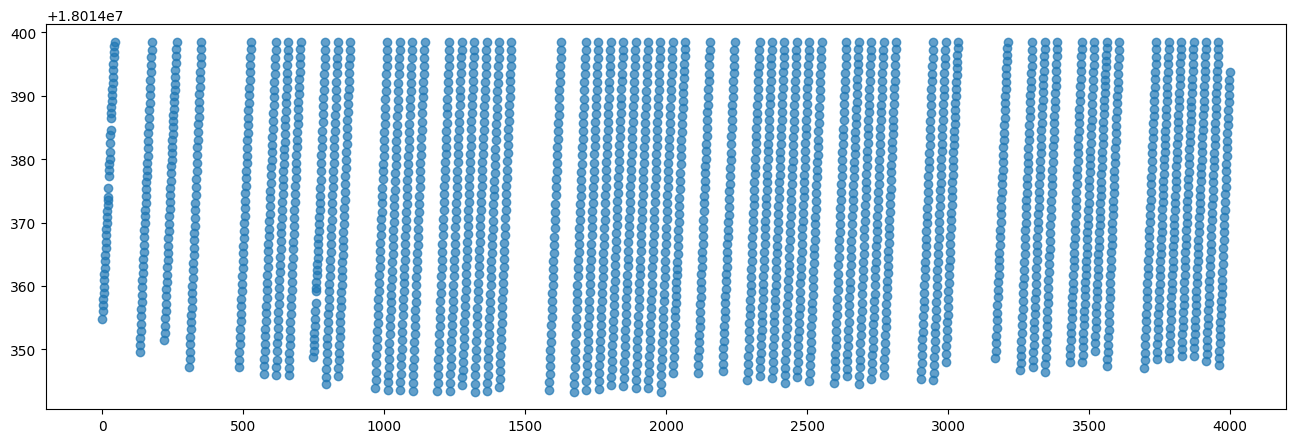

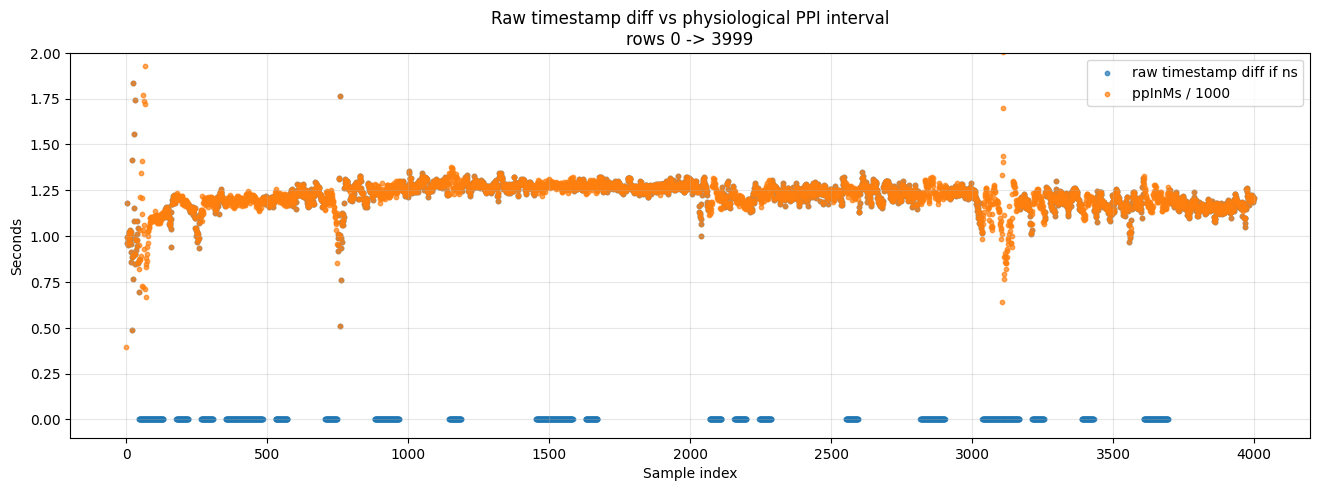

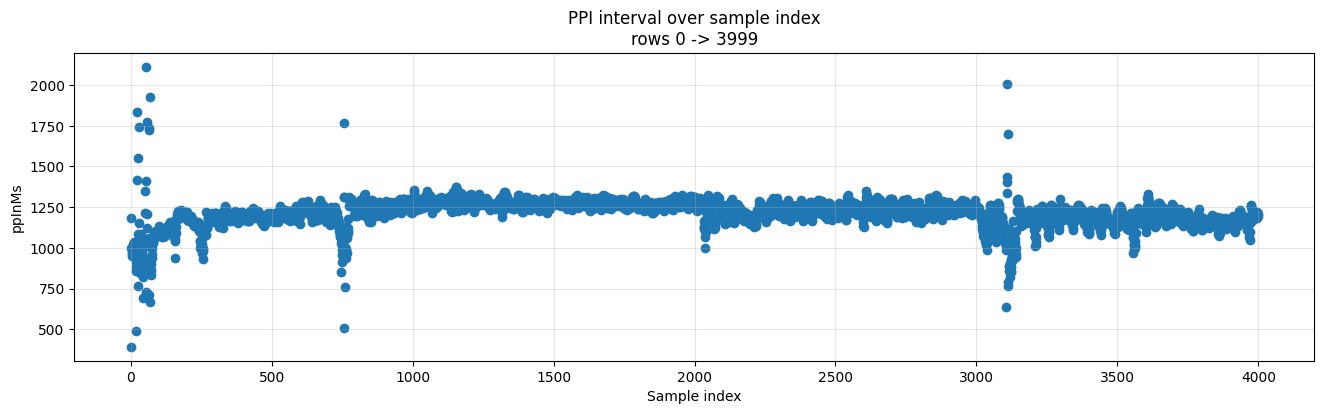

In [55]:
def plot_raw_timestamp_vs_ppi(
    df: pd.DataFrame,
    skip: int = 0,
    take: int = 1000,
    auto_ylim: bool = True,
):
    """
    skip:
        з якого sample почати

    take:
        скільки samples показати

    auto_ylim:
        автоматично підлаштовувати Y-axis
    """

    xdf = df.iloc[skip:skip + take].copy()

    if xdf.empty:
        print("Empty slice")
        return

    print(f"Showing rows: {skip} -> {skip + len(xdf) - 1}")

     # ---------------------------------------------------
    # GRAPH 0
    # ---------------------------------------------------

    plt.figure(figsize=(16, 5))

    plt.scatter(
            xdf[xdf["timeStamp"]>0]["row_idx"],
        xdf[xdf["timeStamp"]>0]["timeStamp"]/1e9,  # Convert to minutes for better scale
        label="raw timestamp diff if ns",
        alpha=0.7
    )

    plt.show()

    # ---------------------------------------------------
    # GRAPH 1
    # ---------------------------------------------------

    plt.figure(figsize=(16, 5))

    plt.scatter(
        xdf["row_idx"],
        xdf["timestamp_diff_s_if_ns"],
        label="raw timestamp diff if ns",
        s=10,
        alpha=0.7
    )

    plt.scatter(
        xdf["row_idx"],
        xdf["pp_s"],
        label="ppInMs / 1000",
        s=10,
        alpha=0.7
    )

    if auto_ylim:
        vals = xdf[["timestamp_diff_s_if_ns", "pp_s"]].to_numpy().flatten()
        vals = vals[np.isfinite(vals)]

        if len(vals) > 0:
            upper = np.nanpercentile(vals, 99)
            upper = min(max(upper * 1.2, 2), 5)
            plt.ylim(-0.1, upper)

    plt.title(
        f"Raw timestamp diff vs physiological PPI interval\n"
        f"rows {skip} -> {skip + len(xdf) - 1}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Seconds")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

    # ---------------------------------------------------
    # GRAPH 2
    # ---------------------------------------------------

    plt.figure(figsize=(16, 4))

    plt.scatter(
        xdf["row_idx"],
        xdf["ppInMs"],
        linewidth=1
    )

    plt.title(
        f"PPI interval over sample index\n"
        f"rows {skip} -> {skip + len(xdf) - 1}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("ppInMs")

    plt.grid(True, alpha=0.3)

    plt.show()
plot_raw_timestamp_vs_ppi(df, skip=0, take=4000)

# Strategy A — Anchor interpolation

Ця стратегія тестує твою ідею:

> знайти два timestamp-и, які реально виглядають валідно, і розподілити/усереднити час між ними.

Ми робимо це не тільки для двох точок, а для всіх знайдених “valid anchors”.
Якщо anchors мало або вони погані — стратегія автоматично стає другорядною.

In [6]:
def detect_timestamp_anchors(
    df: pd.DataFrame,
    min_step_s: float = 0.05,
    max_step_s: float = 10.0,
    allow_first_non_zero: bool = True,
) -> pd.DataFrame:
    out = df.copy()
    diff_s = out["timeStamp"].diff() / 1e9

    anchor = (
        out["timeStamp"].notna()
        & out["timeStamp"].ne(0)
        & diff_s.gt(min_step_s)
        & diff_s.le(max_step_s)
    )

    if allow_first_non_zero:
        idx = out.index[out["timeStamp"].notna() & out["timeStamp"].ne(0)]
        if len(idx):
            anchor.loc[idx[0]] = True

    out["is_timestamp_anchor"] = anchor
    out["anchor_diff_s"] = diff_s.where(anchor)
    return out


def build_anchor_interpolated_timeline(df: pd.DataFrame) -> pd.DataFrame:
    out = detect_timestamp_anchors(df).copy()
    anchors = out[out["is_timestamp_anchor"]].copy()

    out["t_anchor_interp_s"] = np.nan
    out["t_anchor_strategy_note"] = "fallback_cumulative_ppi"

    if len(anchors) >= 2:
        first_ts = anchors["timeStamp"].iloc[0]
        anchor_x = anchors["row_idx"].to_numpy()
        anchor_y = ((anchors["timeStamp"] - first_ts) / 1e9).to_numpy()

        in_range = out["row_idx"].between(anchor_x.min(), anchor_x.max())
        out.loc[in_range, "t_anchor_interp_s"] = np.interp(
            out.loc[in_range, "row_idx"],
            anchor_x,
            anchor_y
        )
        out.loc[in_range, "t_anchor_strategy_note"] = "interpolated_between_valid_anchors"

    elif len(anchors) == 1:
        i = anchors.index[0]
        out.loc[i, "t_anchor_interp_s"] = 0.0
        out.loc[i, "t_anchor_strategy_note"] = "single_anchor_only"

    # Fallback cumulative PPI for zones without anchors.
    pp_s = out["pp_s"].where(out["ppi_physio_plausible"])
    pp_s = pp_s.fillna(pp_s.median())
    fallback = pp_s.cumsum()
    fallback = fallback - fallback.iloc[0]

    has_interp = out["t_anchor_interp_s"].notna()
    if has_interp.any():
        first_i = out.index[has_interp][0]
        offset = out.loc[first_i, "t_anchor_interp_s"] - fallback.loc[first_i]
        fallback = fallback + offset

    out["t_anchor_interp_s"] = out["t_anchor_interp_s"].fillna(fallback)
    out["t_anchor_interp_min"] = out["t_anchor_interp_s"] / 60.0
    return out


df = build_anchor_interpolated_timeline(df)

print("Anchor count:", int(df["is_timestamp_anchor"].sum()))
display(df.loc[df["is_timestamp_anchor"], [
    "row_idx", "timeStamp", "timestamp_diff_s_if_ns", "ppInMs",
    "hr", "ppErrorEstimate", "blockerBit"
]].head(30))

Anchor count: 15567


,row_idx,timeStamp,timestamp_diff_s_if_ns,ppInMs,hr,ppErrorEstimate,blockerBit
0,0,18014354808481984,NaN,393,0,30,1
1,1,18014355991481984,1.183,1183,0,30,1
2,2,18014356988481984,0.997,997,0,30,1
3,3,18014357950481984,0.962,962,0,30,0
4,4,18014358945481984,0.995,995,0,30,1
5,5,18014359898481984,0.953,953,0,30,0
6,6,18014360874481984,0.976,976,0,30,0
7,7,18014361872481984,0.998,998,0,30,0
8,8,18014362867481984,0.995,995,0,25,0
9,9,18014363888481984,1.021,1021,0,20,0


# Strategy B — Cumulative PPI reconstruction

Це друга стратегія:

> взяти стартову точку і будувати час через накопичення `ppInMs`.

Для PPI це часто найстабільніший варіант, бо `ppInMs` сам по собі є інтервалом між ударами.

In [7]:
def build_cumulative_ppi_timeline(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    pp_s = out["pp_s"].where(out["ppi_physio_plausible"])
    pp_s = pp_s.fillna(pp_s.median())

    out["pp_s_for_reconstruction"] = pp_s
    out["t_ppi_reconstructed_s"] = pp_s.cumsum()
    out["t_ppi_reconstructed_s"] = out["t_ppi_reconstructed_s"] - out["t_ppi_reconstructed_s"].iloc[0]
    out["t_ppi_reconstructed_min"] = out["t_ppi_reconstructed_s"] / 60.0
    return out


df = build_cumulative_ppi_timeline(df)

raw_duration_s = (df["timeStamp"].max() - df["timeStamp"].min()) / 1e9
a_duration_s = df["t_anchor_interp_s"].max() - df["t_anchor_interp_s"].min()
b_duration_s = df["t_ppi_reconstructed_s"].max() - df["t_ppi_reconstructed_s"].min()

print(f"Raw duration if ns: {raw_duration_s:,.2f}s = {raw_duration_s/3600:,.2f}h")
print(f"Strategy A duration: {a_duration_s:,.2f}s = {a_duration_s/60:,.2f}min")
print(f"Strategy B duration: {b_duration_s:,.2f}s = {b_duration_s/60:,.2f}min")

display(df[[
    "row_idx", "timeStamp", "ppInMs",
    "t_anchor_interp_s", "t_ppi_reconstructed_s",
    "t_anchor_strategy_note"
]].head(20))

Raw duration if ns: 18,014,398.51s = 5,004.00h
Strategy A duration: 30,276.09s = 504.60min
Strategy B duration: 30,258.77s = 504.31min


,row_idx,timeStamp,ppInMs,t_anchor_interp_s,t_ppi_reconstructed_s,t_anchor_strategy_note
0,0,18014354808481984,393,0.000,0.000,interpolated_between_valid_anchors
1,1,18014355991481984,1183,1.183,1.183,interpolated_between_valid_anchors
2,2,18014356988481984,997,2.180,2.180,interpolated_between_valid_anchors
3,3,18014357950481984,962,3.142,3.142,interpolated_between_valid_anchors
4,4,18014358945481984,995,4.137,4.137,interpolated_between_valid_anchors
5,5,18014359898481984,953,5.090,5.090,interpolated_between_valid_anchors
6,6,18014360874481984,976,6.066,6.066,interpolated_between_valid_anchors
7,7,18014361872481984,998,7.064,7.064,interpolated_between_valid_anchors
8,8,18014362867481984,995,8.059,8.059,interpolated_between_valid_anchors
9,9,18014363888481984,1021,9.080,9.080,interpolated_between_valid_anchors


## 5. Compare both strategies

Тут найважливіше:

- якщо Strategy A і Strategy B сильно розходяться — raw timestamps не мають достатньо валідних anchors;
- якщо Strategy B дає фізіологічно реалістичну тривалість — її можна взяти як primary PPI timeline;
- Strategy A можна залишити як diagnostic/secondary alignment.

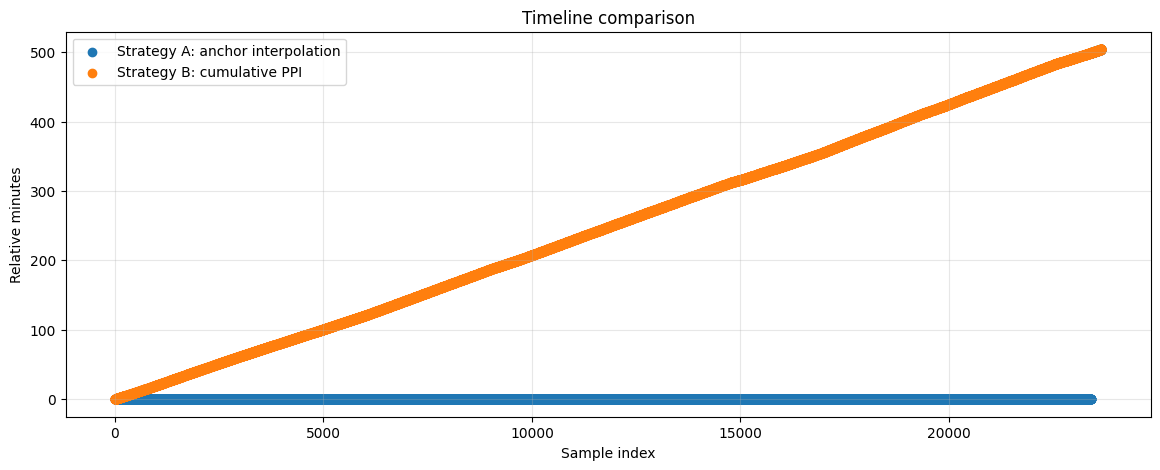

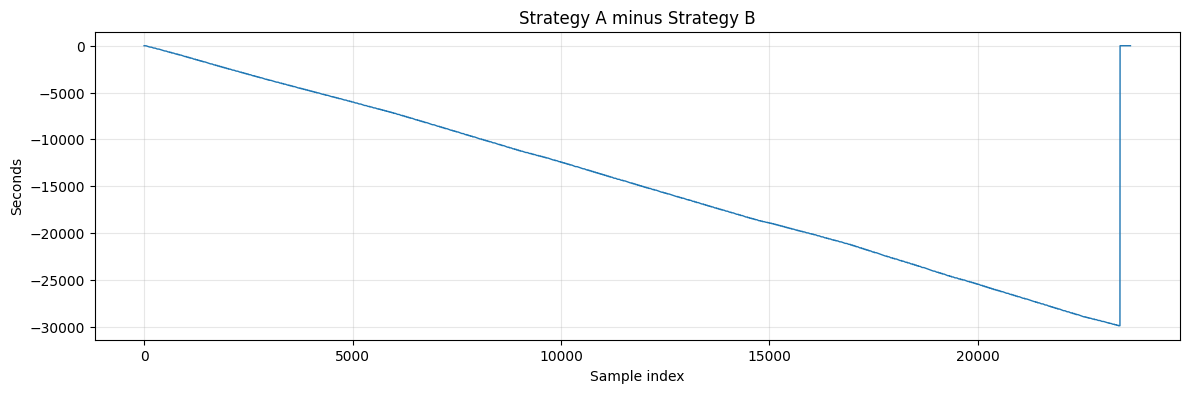

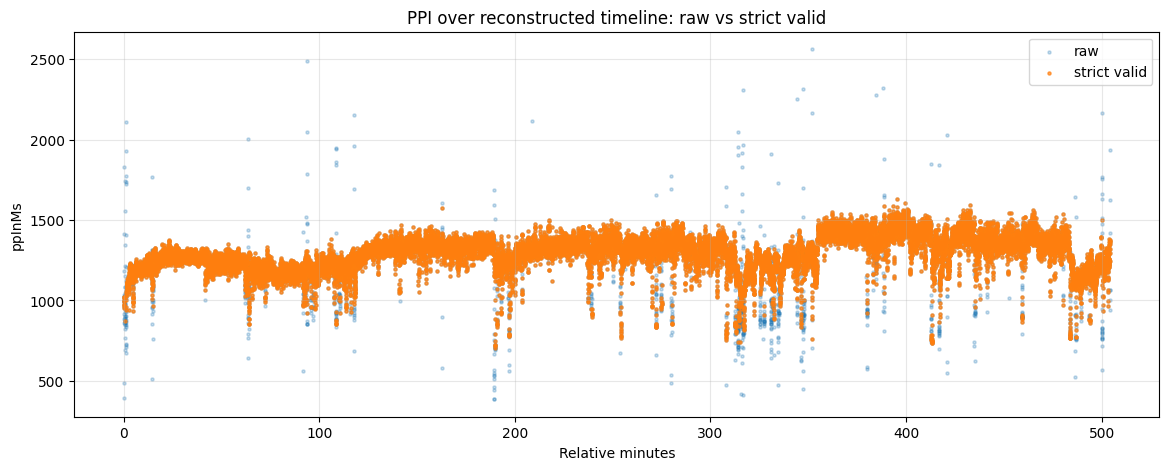

In [27]:
plt.figure(figsize=(14, 5))
plt.scatter(df["row_idx"], df["t_anchor_interp_min"], label="Strategy A: anchor interpolation", linewidth=1)
plt.scatter(df["row_idx"], df["t_ppi_reconstructed_min"], label="Strategy B: cumulative PPI", linewidth=1)
plt.title("Timeline comparison")
plt.xlabel("Sample index")
plt.ylabel("Relative minutes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df["row_idx"], df["t_anchor_interp_s"] - df["t_ppi_reconstructed_s"], linewidth=1)
plt.title("Strategy A minus Strategy B")
plt.xlabel("Sample index")
plt.ylabel("Seconds")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.scatter(df["t_ppi_reconstructed_min"], df["ppInMs"], s=5, alpha=0.25, label="raw")
valid = df[df["valid_candidate_strict"]]
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=5, alpha=0.7, label="strict valid")
plt.title("PPI over reconstructed timeline: raw vs strict valid")
plt.xlabel("Relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Timestamp quality taxonomy

Цю колонку варто потім перенести в normalizer/time alignment report.

,count
timestamp_quality_class,
okish_anchor_candidate,15566
zero_timestamp,7732
negative_timestamp,253
huge_jump,108
unknown_or_first_sample,1


,pct
timestamp_quality_class,
okish_anchor_candidate,65.790
zero_timestamp,32.680
negative_timestamp,1.069
huge_jump,0.456
unknown_or_first_sample,0.004


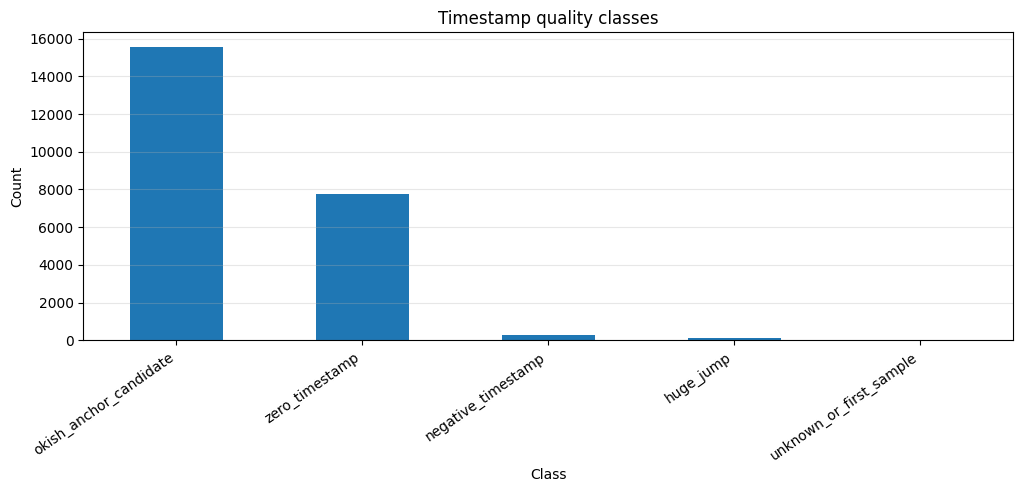

In [9]:
def classify_timestamp_quality(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    diff_s = out["timestamp_diff_s_if_ns"]

    conditions = [
        out["timeStamp"].eq(0),
        diff_s.eq(0),
        diff_s.lt(0),
        diff_s.gt(10),
        diff_s.between(0, 0.05, inclusive="neither"),
        diff_s.between(0.05, 10, inclusive="both"),
    ]
    choices = [
        "zero_timestamp",
        "duplicate_timestamp",
        "negative_timestamp",
        "huge_jump",
        "too_fast_for_beat_time",
        "okish_anchor_candidate",
    ]

    out["timestamp_quality_class"] = np.select(
        conditions,
        choices,
        default="unknown_or_first_sample"
    )
    return out


df = classify_timestamp_quality(df)

display(df["timestamp_quality_class"].value_counts(dropna=False).to_frame("count"))
display((100 * df["timestamp_quality_class"].value_counts(dropna=False) / len(df)).round(3).to_frame("pct"))

plt.figure(figsize=(12, 4))
df["timestamp_quality_class"].value_counts().plot(kind="bar")
plt.title("Timestamp quality classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 7. Filtering effect demonstration

Показуємо, як quality filtering прибирає blocker/outlier samples, але raw дані залишаються доступними.

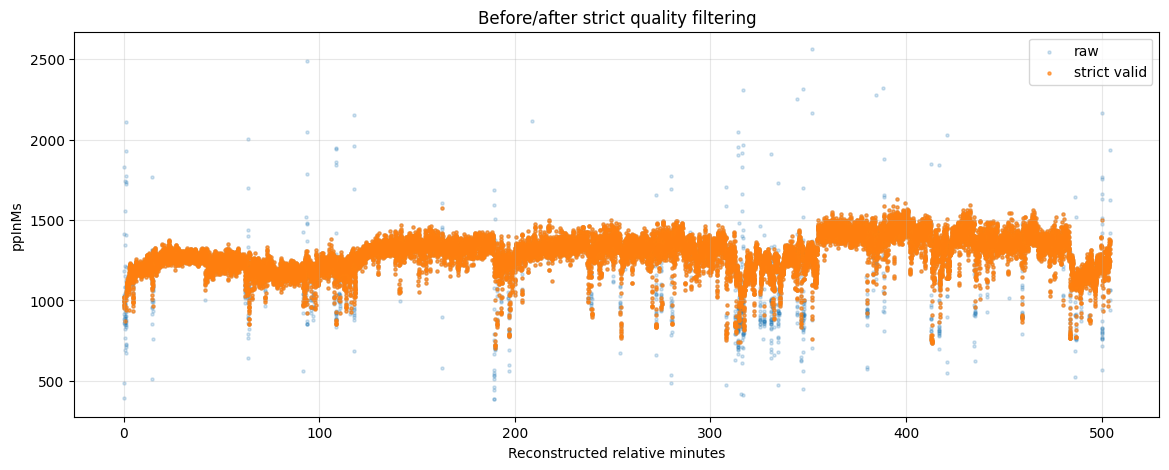

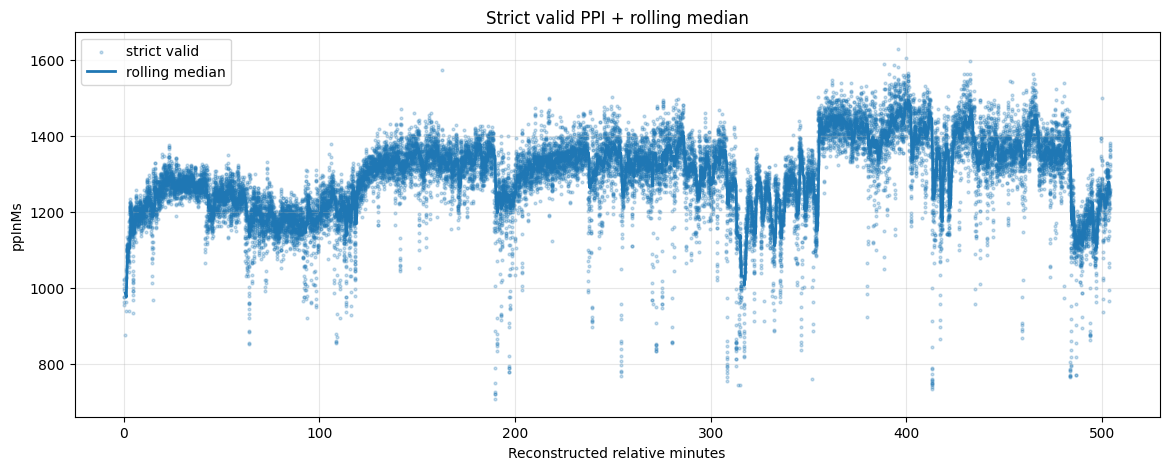

In [10]:
plt.figure(figsize=(14, 5))
plt.scatter(df["t_ppi_reconstructed_min"], df["ppInMs"], s=5, alpha=0.2, label="raw")
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=5, alpha=0.65, label="strict valid")
plt.title("Before/after strict quality filtering")
plt.xlabel("Reconstructed relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

smooth = valid.set_index("t_ppi_reconstructed_s")["ppInMs"].rolling(window=60, min_periods=10).median()

plt.figure(figsize=(14, 5))
plt.scatter(valid["t_ppi_reconstructed_min"], valid["ppInMs"], s=4, alpha=0.25, label="strict valid")
plt.plot(smooth.index / 60.0, smooth.values, linewidth=2, label="rolling median")
plt.title("Strict valid PPI + rolling median")
plt.xlabel("Reconstructed relative minutes")
plt.ylabel("ppInMs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. ML-oriented window features

Це підготовка до sleep/ML features:

- valid ratio
- median PPI
- mean HR
- SDNN
- RMSSD
- pNN50
- quality score
- blocker ratio
- pp error median

In [11]:
def rmssd_ms(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 3:
        return np.nan
    return float(np.sqrt(np.mean(np.diff(x) ** 2)))

def sdnn_ms(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1))

def pnn50(pp_ms: pd.Series) -> float:
    x = pp_ms.dropna().to_numpy()
    if len(x) < 3:
        return np.nan
    return float(np.mean(np.abs(np.diff(x)) > 50))

def build_window_features(df: pd.DataFrame, window_s: int) -> pd.DataFrame:
    x = df.copy()
    x["window_id"] = np.floor(x["t_ppi_reconstructed_s"] / window_s).astype(int)

    rows = []
    for wid, g in x.groupby("window_id", sort=True):
        valid_g = g[g["valid_candidate_strict"]]
        rows.append({
            "window_id": wid,
            "window_start_s": wid * window_s,
            "window_start_min": wid * window_s / 60,
            "window_s": window_s,
            "n_samples": len(g),
            "n_valid": len(valid_g),
            "valid_ratio": len(valid_g) / len(g) if len(g) else np.nan,
            "median_pp_ms": valid_g["ppInMs"].median(),
            "mean_pp_ms": valid_g["ppInMs"].mean(),
            "median_hr": valid_g["hr"].replace(0, np.nan).median(),
            "mean_hr": valid_g["hr"].replace(0, np.nan).mean(),
            "sdnn_ms": sdnn_ms(valid_g["ppInMs"]),
            "rmssd_ms": rmssd_ms(valid_g["ppInMs"]),
            "pnn50": pnn50(valid_g["ppInMs"]),
            "mean_quality_score": g["quality_score_0_1"].mean(),
            "blocker_ratio": 1 - g["not_blocked"].mean(),
            "pp_error_median": g["ppErrorEstimate"].median(),
            "contact_ratio": g["valid_contact"].mean(),
        })

    return pd.DataFrame(rows)

features_30s = build_window_features(df, 30)
features_60s = build_window_features(df, 60)
features_5m = build_window_features(df, 300)

display(features_30s.head())
display(features_30s.describe(percentiles=[0.05, 0.5, 0.95]).T)

,window_id,window_start_s,window_start_min,window_s,n_samples,n_valid,valid_ratio,median_pp_ms,mean_pp_ms,median_hr,mean_hr,sdnn_ms,rmssd_ms,pnn50,mean_quality_score,blocker_ratio,pp_error_median,contact_ratio
0,0,0,0.0,30,30,9,0.300000,995.0,990.222222,NaN,NaN,25.425272,20.118400,0.0,0.652900,0.700000,30.0,1.0
1,1,30,0.5,30,29,1,0.034483,874.0,874.000000,NaN,NaN,NaN,NaN,NaN,0.593655,0.931034,36.0,1.0
2,2,60,1.0,30,27,12,0.444444,1047.0,1037.083333,56.0,56.545455,49.798610,18.278154,0.0,0.734667,0.296296,46.0,1.0
3,3,90,1.5,30,28,28,1.000000,1098.0,1096.714286,55.0,54.678571,15.136067,15.861671,0.0,0.971821,0.000000,9.0,1.0
4,4,120,2.0,30,27,27,1.000000,1108.0,1109.740741,54.0,53.962963,20.783856,19.544820,0.0,0.972111,0.000000,9.0,1.0


,count,mean,std,min,5%,50%,95%,max
window_id,1009.0,504.000000,291.417513,0.000000,50.400000,504.000000,957.600000,1008.000000
window_start_s,1009.0,15120.000000,8742.525379,0.000000,1512.000000,15120.000000,28728.000000,30240.000000
window_start_min,1009.0,252.000000,145.708756,0.000000,25.200000,252.000000,478.800000,504.000000
window_s,1009.0,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
n_samples,1009.0,23.448959,2.083005,15.000000,21.000000,23.000000,27.000000,35.000000
n_valid,1009.0,22.454906,2.974795,0.000000,17.400000,23.000000,26.000000,29.000000
valid_ratio,1009.0,0.963852,0.127523,0.000000,0.652174,1.000000,1.000000,1.000000
median_pp_ms,1008.0,1295.388393,96.763854,810.500000,1142.525000,1313.750000,1437.000000,1520.000000
mean_pp_ms,1008.0,1291.680985,97.833467,855.375000,1130.227000,1310.911067,1431.395238,1521.052632
median_hr,1006.0,46.498012,3.615197,30.000000,42.000000,46.000000,52.000000,73.000000


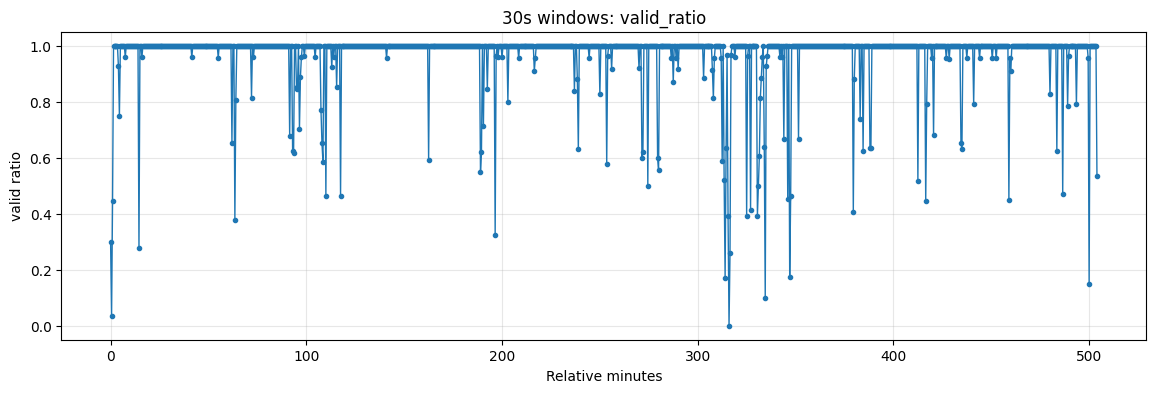

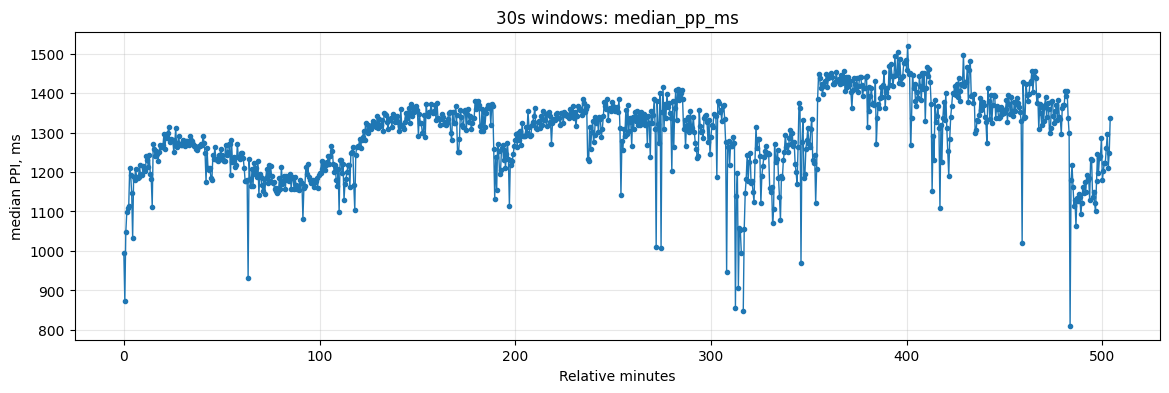

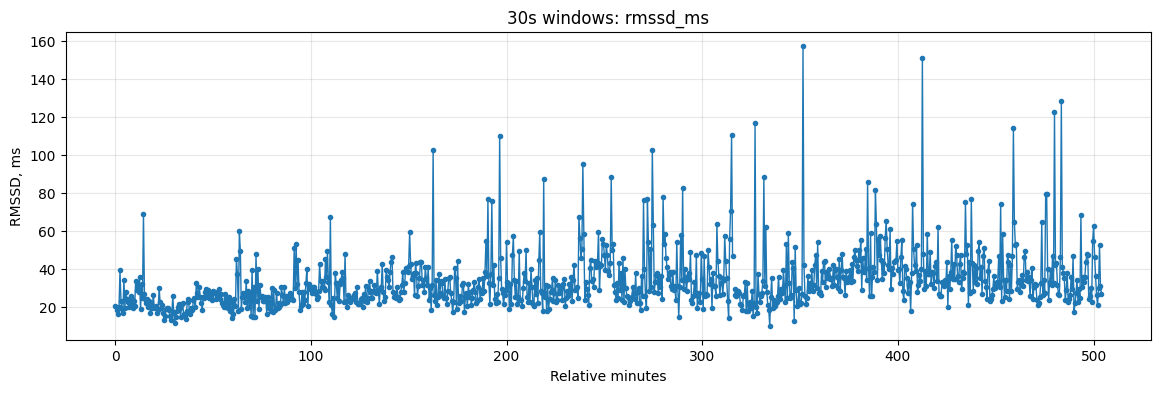

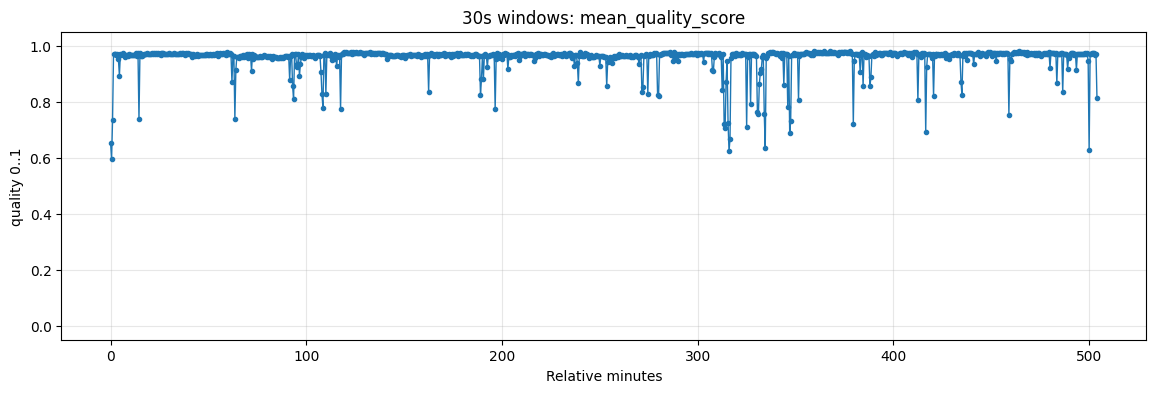

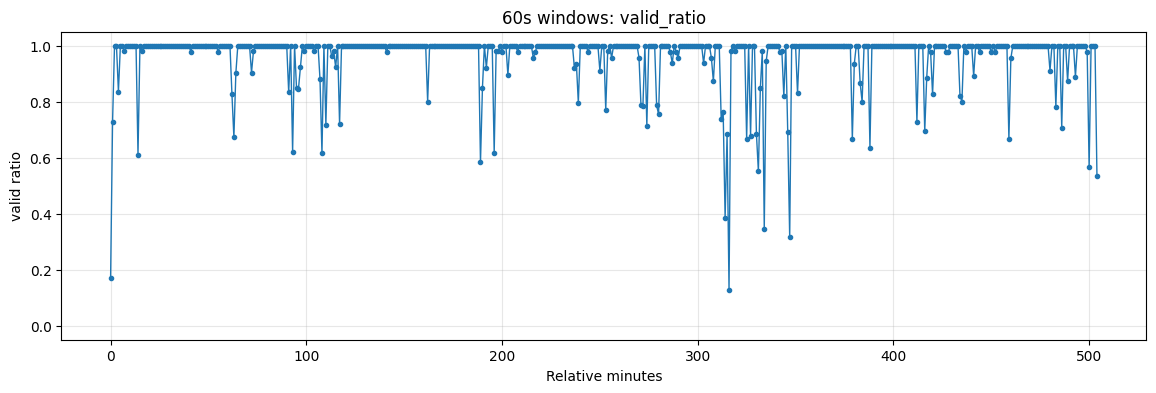

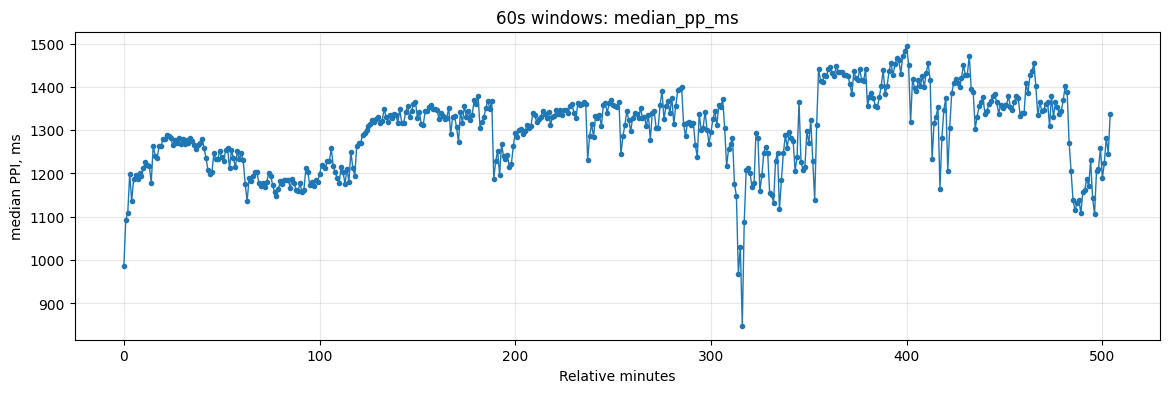

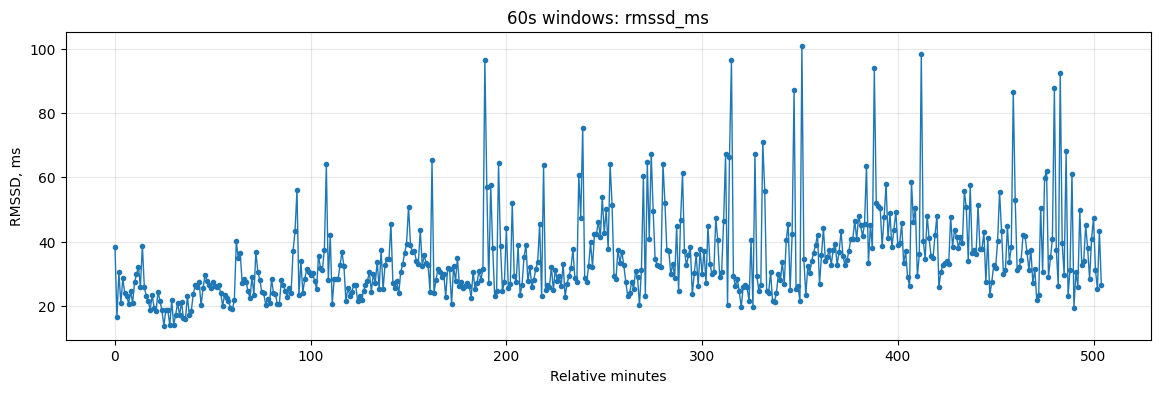

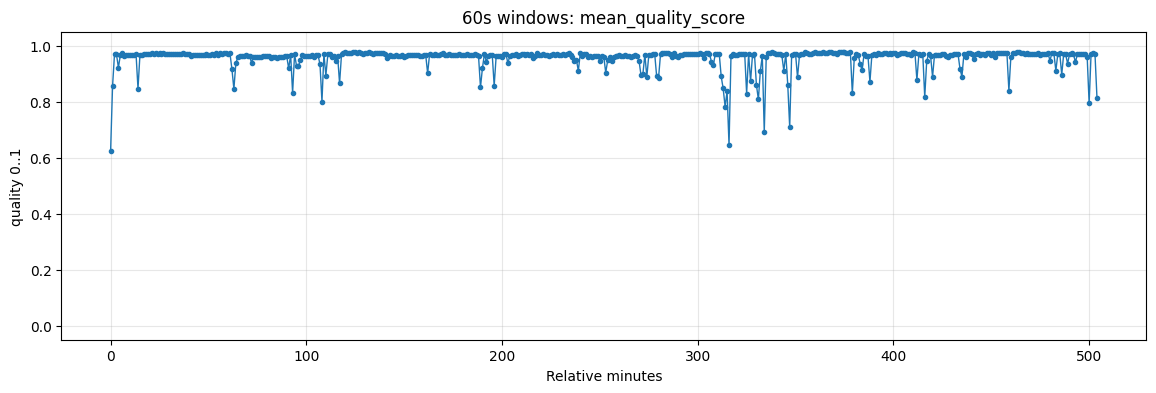

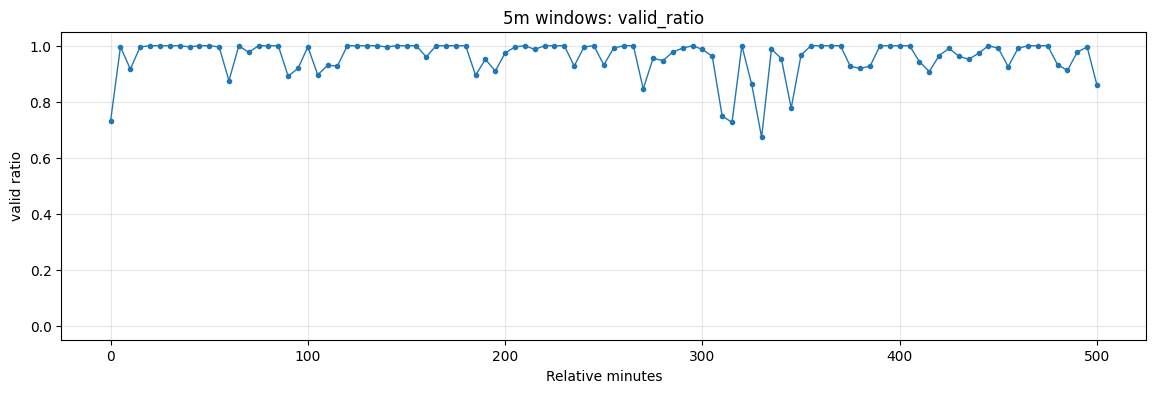

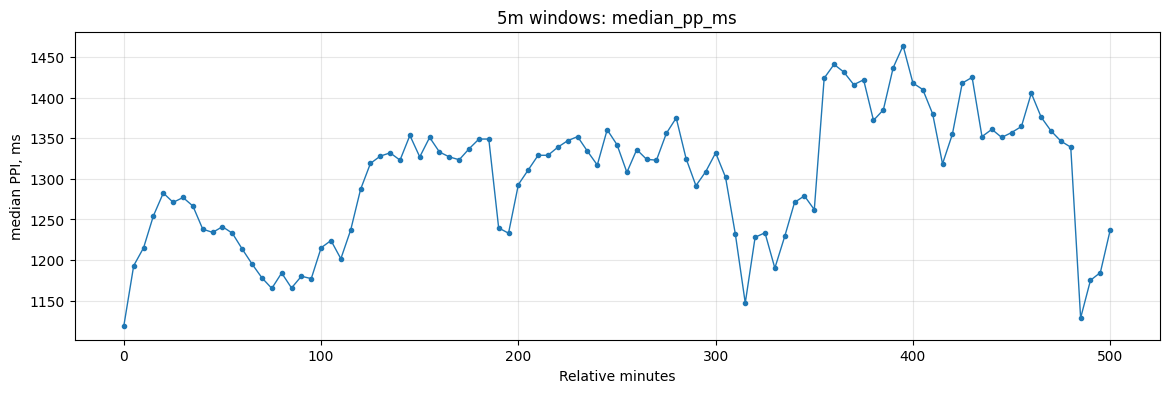

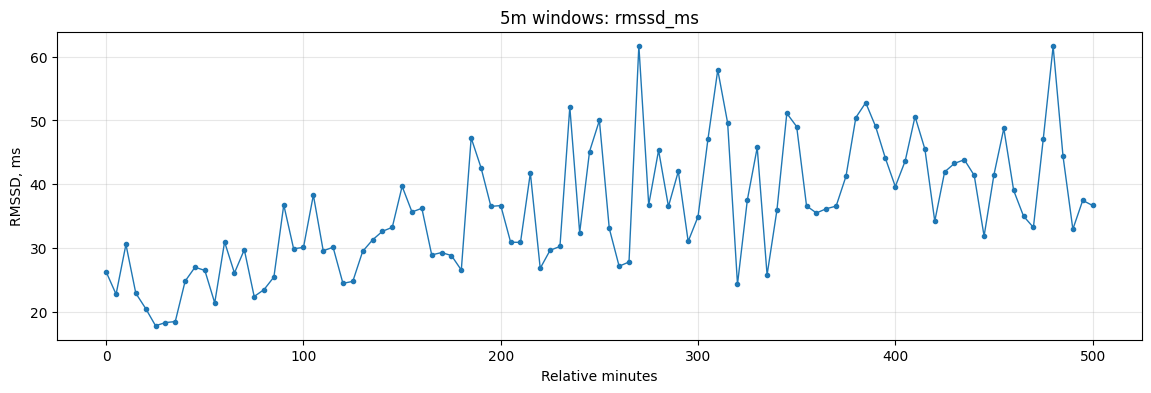

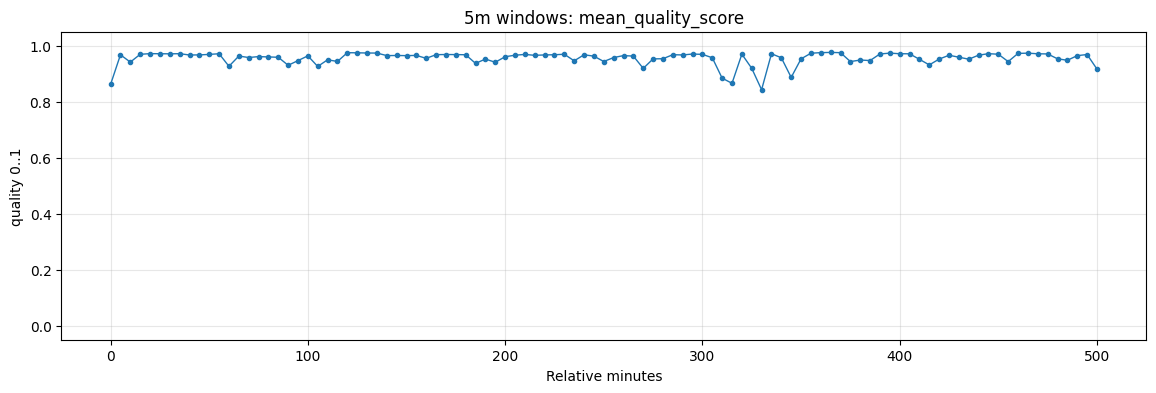

In [12]:
def plot_window_features(features: pd.DataFrame, title: str):
    for col, ylabel in [
        ("valid_ratio", "valid ratio"),
        ("median_pp_ms", "median PPI, ms"),
        ("rmssd_ms", "RMSSD, ms"),
        ("mean_quality_score", "quality 0..1"),
    ]:
        plt.figure(figsize=(14, 4))
        plt.plot(features["window_start_min"], features[col], marker=".", linewidth=1)
        plt.title(f"{title}: {col}")
        plt.xlabel("Relative minutes")
        plt.ylabel(ylabel)
        if col in ["valid_ratio", "mean_quality_score"]:
            plt.ylim(-0.05, 1.05)
        plt.grid(True, alpha=0.3)
        plt.show()

plot_window_features(features_30s, "30s windows")
plot_window_features(features_60s, "60s windows")
plot_window_features(features_5m, "5m windows")

## 9. Decision report

Це summary можна використати як основу для `time_alignment_report.json`.

In [13]:
def make_decision_report(df: pd.DataFrame) -> dict:
    raw_duration_s = float((df["timeStamp"].max() - df["timeStamp"].min()) / 1e9)
    a_duration_s = float(df["t_anchor_interp_s"].max() - df["t_anchor_interp_s"].min())
    b_duration_s = float(df["t_ppi_reconstructed_s"].max() - df["t_ppi_reconstructed_s"].min())

    return {
        "sample_count": int(len(df)),
        "raw_timestamp": {
            "monotonic_non_decreasing": bool(df["timeStamp"].is_monotonic_increasing),
            "duplicate_count": int(df["timeStamp"].duplicated().sum()),
            "duplicate_ratio": float(df["timeStamp"].duplicated().mean()),
            "zero_count": int(df["timeStamp"].eq(0).sum()),
            "zero_ratio": float(df["timeStamp"].eq(0).mean()),
            "duration_if_ns_seconds": raw_duration_s,
            "usable_as_primary_beat_time": False,
        },
        "strategy_a_anchor_interpolation": {
            "anchor_count": int(df["is_timestamp_anchor"].sum()),
            "duration_seconds": a_duration_s,
            "duration_minutes": a_duration_s / 60,
            "recommended_role": "secondary_diagnostic",
        },
        "strategy_b_cumulative_ppi": {
            "duration_seconds": b_duration_s,
            "duration_minutes": b_duration_s / 60,
            "recommended_role": "primary_ppi_beat_timeline",
        },
        "quality": {
            "valid_candidate_strict_ratio": float(df["valid_candidate_strict"].mean()),
            "valid_candidate_relaxed_ratio": float(df["valid_candidate_relaxed"].mean()),
            "blocker_ratio": float((~df["not_blocked"]).mean()),
            "pp_error_median": float(df["ppErrorEstimate"].median()),
            "skin_contact_ratio": float(df["valid_contact"].mean()),
        },
        "normalizer_recommendation": {
            "preserve_raw_timeStamp": True,
            "add_t_ppi_reconstructed_s": True,
            "add_t_anchor_interp_s_as_diagnostic": True,
            "add_timestamp_quality_class": True,
            "add_quality_score_0_1": True,
            "add_valid_candidate_flags": True,
        },
    }

decision_report = make_decision_report(df)
print(json.dumps(decision_report, indent=2))

{
  "sample_count": 23660,
  "raw_timestamp": {
    "monotonic_non_decreasing": false,
    "duplicate_count": 10181,
    "duplicate_ratio": 0.43030431107354183,
    "zero_count": 7732,
    "zero_ratio": 0.3267962806424345,
    "duration_if_ns_seconds": 18014398.509481985,
    "usable_as_primary_beat_time": false
  },
  "strategy_a_anchor_interpolation": {
    "anchor_count": 15567,
    "duration_seconds": 30276.08500000023,
    "duration_minutes": 504.60141666667045,
    "recommended_role": "secondary_diagnostic"
  },
  "strategy_b_cumulative_ppi": {
    "duration_seconds": 30258.76500000023,
    "duration_minutes": 504.3127500000038,
    "recommended_role": "primary_ppi_beat_timeline"
  },
  "quality": {
    "valid_candidate_strict_ratio": 0.957607776838546,
    "valid_candidate_relaxed_ratio": 0.9618343195266272,
    "blocker_ratio": 0.03647506339814032,
    "pp_error_median": 10.0,
    "skin_contact_ratio": 1.0
  },
  "normalizer_recommendation": {
    "preserve_raw_timeStamp": true

## 10. Export debug artifacts

Це створить локальну папку поруч з notebook runtime:

- `ppi_time_aligned_debug.csv`
- `ppi_features_30s.csv`
- `ppi_features_60s.csv`
- `ppi_features_5m.csv`
- `ppi_time_alignment_report.json`

Raw `chunks.jsonl` не змінюється.

In [14]:
EXPORT_DIR = Path("./ppi_time_alignment_debug_outputs")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

debug_cols = [
    "row_idx", "line_no", "sample_idx_in_chunk", "sequence",
    "timeStamp", "timestamp_diff_raw", "timestamp_diff_s_if_ns", "timestamp_quality_class",
    "is_timestamp_anchor", "t_anchor_interp_s", "t_anchor_interp_min",
    "t_ppi_reconstructed_s", "t_ppi_reconstructed_min",
    "ppInMs", "pp_s", "hr", "ppErrorEstimate", "blockerBit",
    "skinContactSupported", "skinContactStatus",
    "valid_contact", "not_blocked", "pp_error_ok_strict", "pp_error_ok_relaxed",
    "ppi_physio_plausible", "valid_candidate_strict", "valid_candidate_relaxed",
    "quality_score_0_1",
]
debug_df = df[[c for c in debug_cols if c in df.columns]].copy()

debug_df.to_csv(EXPORT_DIR / "ppi_time_aligned_debug.csv", index=False)
features_30s.to_csv(EXPORT_DIR / "ppi_features_30s.csv", index=False)
features_60s.to_csv(EXPORT_DIR / "ppi_features_60s.csv", index=False)
features_5m.to_csv(EXPORT_DIR / "ppi_features_5m.csv", index=False)

with (EXPORT_DIR / "ppi_time_alignment_report.json").open("w", encoding="utf-8") as f:
    json.dump(decision_report, f, indent=2)

print("Exported to:", EXPORT_DIR.resolve())

Exported to: /Users/maksymponomarenko/Documents/homelab/notebooks/ppi_time_alignment_debug_outputs


# Practical conclusion

Після запуску notebook:

- Якщо raw timestamp duration абсурдний — не використовуй `timeStamp` як primary beat time.
- Якщо anchors мало або Strategy A сильно розходиться зі Strategy B — anchor interpolation лишити як diagnostic.
- Якщо cumulative PPI duration виглядає реалістично — брати Strategy B як primary PPI timeline.
- Для CP14 normalizer:
  - preserve raw `timeStamp`
  - add `t_ppi_reconstructed_s`
  - add `timestamp_quality_class`
  - add `quality_score_0_1`
  - add `valid_candidate_*`
  - emit `time_alignment_report.json`